In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import pymc as pm
import pytensor.tensor as pt
import arviz as az

plt.rcParams["figure.dpi"] = 150

panel_path = r"C:\Users\Tosin\Downloads\BMC\panel_A_balanced_zero_weeks_climate_complete.csv"
rain_path  = r"C:\Users\Tosin\Downloads\BMC\rain_weekly_by_municipality_FIXED.csv"
shp_path   = r"C:\Users\Tosin\Downloads\BMC\Municipal\00mun.shp"

# Load data
panel = pd.read_csv(panel_path)
rain = pd.read_csv(rain_path)

panel["muni_code"] = pd.to_numeric(panel["muni_code"], errors="coerce").astype("Int64")
rain["CVEGEO"] = pd.to_numeric(rain["CVEGEO"], errors="coerce").astype("Int64")

rain_small = rain[["CVEGEO", "iso_year", "iso_week", "rain_mm_week"]].copy()
rain_small = rain_small.rename(columns={"CVEGEO": "muni_code"})

panel = panel.merge(rain_small, on=["muni_code", "iso_year", "iso_week"], how="left")

# Keep 2020–2025 with rainfall available
panel = panel[(panel["iso_year"].between(2020, 2025)) & (panel["rain_mm_week"].notna())].copy()

# Annual summaries per municipality per year
annual_all = panel.groupby(["iso_year", "muni_code"], as_index=False).agg(
    cases=("total_cases", "sum"),
    rain_sum=("rain_mm_week", "sum"),
    temp_mean=("t2m_mean", "mean"),
    rh_mean=("rh2m_mean", "mean"),
    weeks=("iso_week", "nunique"),
)

# Load shapefile and align municipalities
mun = gpd.read_file(shp_path)
mun["muni_code"] = pd.to_numeric(mun["CVEGEO"], errors="coerce").astype("Int64")
mun = mun.dropna(subset=["muni_code"]).copy()
mun["muni_code"] = mun["muni_code"].astype(int)

# Keep only municipalities present in annual_all
present = set(pd.to_numeric(annual_all["muni_code"], errors="coerce").dropna().astype(int).unique())
mun = mun[mun["muni_code"].isin(present)].copy()

mun = mun.sort_values("muni_code").reset_index(drop=True)
mun["muni_idx"] = np.arange(mun.shape[0], dtype=int)

# Merge muni_idx into annual table
annual_all["muni_code"] = pd.to_numeric(annual_all["muni_code"], errors="coerce").astype(int)
annual_all = annual_all.merge(mun[["muni_code", "muni_idx"]], on="muni_code", how="inner")

# Build adjacency W on mun
sindex = mun.sindex
geoms = mun.geometry

neighbors = []
for i, geom in enumerate(geoms):
    cand = list(sindex.intersection(geom.bounds))
    cand = [j for j in cand if j != i]
    neigh = []
    for j in cand:
        if geom.touches(geoms.iloc[j]):
            neigh.append(j)
    neighbors.append(neigh)

row = []
col = []
dat = []
for i, neigh in enumerate(neighbors):
    for j in neigh:
        row.append(i)
        col.append(j)
        dat.append(1)

n_muni = mun.shape[0]
W = sp.csr_matrix((dat, (row, col)), shape=(n_muni, n_muni))
W = ((W + W.T) > 0).astype(float).tocsr()

deg = np.array(W.sum(axis=1)).reshape(-1)
print("municipalities:", n_muni, "isolates:", int((deg == 0).sum()))

# Fix isolates if needed
if (deg == 0).any():
    from sklearn.neighbors import NearestNeighbors
    cent = mun.geometry.centroid
    coords = np.column_stack([cent.x.to_numpy(), cent.y.to_numpy()])
    nn = NearestNeighbors(n_neighbors=2).fit(coords)
    idxs = nn.kneighbors(coords, return_distance=False)

    W_lil = W.tolil()
    for i in np.where(deg == 0)[0]:
        j = int(idxs[i, 1])
        W_lil[i, j] = 1
        W_lil[j, i] = 1
    W = W_lil.tocsr()

# Build design arrays
years = sorted(annual_all["iso_year"].unique().tolist())
year_to_k = {y:i for i,y in enumerate(years)}
annual_all["year_k"] = annual_all["iso_year"].map(year_to_k).astype(int)

y = annual_all["cases"].to_numpy(dtype=np.int32)
idx_m = annual_all["muni_idx"].to_numpy(dtype=np.int32)
idx_y = annual_all["year_k"].to_numpy(dtype=np.int32)

X = annual_all[["temp_mean", "rain_sum", "rh_mean"]].copy()
Xz = X.sub(X.mean()).div(X.std(ddof=0)).to_numpy(dtype="float32")

n_year = len(years)

with pm.Model() as pooled_model:
    intercept = pm.Normal("intercept", 0, 2)
    beta = pm.Normal("beta", 0, 1, shape=3)

    # year effects with sum-to-zero constraint for identifiability
    sigma_year = pm.HalfNormal("sigma_year", 1.0)
    year_raw = pm.Normal("year_raw", 0, 1, shape=n_year)
    year_eff = pm.Deterministic("year_eff", (year_raw - pt.mean(year_raw)) * sigma_year)

    alpha = pm.Beta("alpha", 2, 2)
    tau = pm.HalfNormal("tau", 1.0)
    u = pm.CAR("u", mu=pt.zeros(n_muni), W=W, alpha=alpha, tau=tau, shape=n_muni)
    u_centered = pm.Deterministic("u_centered", u - pt.mean(u))

    eta = intercept + pt.dot(Xz, beta) + year_eff[idx_y] + u_centered[idx_m]
    mu = pt.exp(eta)

    disp = pm.HalfNormal("disp", 2.0)
    pm.NegativeBinomial("cases", mu=mu, alpha=disp, observed=y)

    cb = pm.callbacks.CheckParametersConvergence(tolerance=5e-4)
    approx = pm.fit(12000, method="advi", callbacks=[cb], random_seed=42)
    idata_pool = approx.sample(1500, random_seed=42)

print(az.summary(idata_pool, var_names=["beta", "sigma_year", "alpha", "tau", "disp"]))

# Climate coefficient summary for Figure 8 later
beta_post = idata_pool.posterior["beta"].to_numpy()
beta_flat = beta_post.reshape(-1, beta_post.shape[-1])

beta_summary = pd.DataFrame({
    "covariate": ["temp_z", "rain_z", "rh_z"],
    "mean": beta_flat.mean(axis=0),
    "hdi_2.5": np.quantile(beta_flat, 0.025, axis=0),
    "hdi_97.5": np.quantile(beta_flat, 0.975, axis=0),
    "exp_mean": np.exp(beta_flat.mean(axis=0)),
    "exp_2.5": np.exp(np.quantile(beta_flat, 0.025, axis=0)),
    "exp_97.5": np.exp(np.quantile(beta_flat, 0.975, axis=0)),
})
print(beta_summary)

# Pooled residual spatial surface: posterior mean log-scale u_centered
u_post = idata_pool.posterior["u_centered"].to_numpy()
u_mean = u_post.mean(axis=(0,1))

mun_map = mun.copy()
mun_map["log_residual_burden"] = u_mean



WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


municipalities: 2469 isolates: 68


C:\Users\Tosin\Anaconda3\Conda\envs\chirps_netcdf\Lib\site-packages\pytensor\tensor\rewriting\elemwise.py:881: UserWarning: Loop fusion failed because the resulting node would exceed the kernel argument limit.
  warn(


Output()

Finished [100%]: Average Loss = 35,382
arviz - WARNING - Shape validation failed: input_shape: (1, 1500), minimum_shape: (chains=2, draws=4)


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]     1.078  0.115   0.860    1.285      0.003    0.002    1190.0   
beta[1]     0.025  0.109  -0.163    0.244      0.003    0.002    1295.0   
beta[2]    -0.095  0.105  -0.287    0.096      0.003    0.002    1481.0   
sigma_year  0.869  0.123   0.629    1.084      0.003    0.003    1491.0   
alpha       0.946  0.019   0.908    0.975      0.000    0.000    1532.0   
tau         0.150  0.018   0.117    0.184      0.000    0.000    1472.0   
disp        0.357  0.061   0.247    0.470      0.002    0.001    1577.0   

            ess_tail  r_hat  
beta[0]       1448.0    NaN  
beta[1]       1294.0    NaN  
beta[2]       1270.0    NaN  
sigma_year    1412.0    NaN  
alpha         1388.0    NaN  
tau           1428.0    NaN  
disp          1438.0    NaN  
  covariate      mean   hdi_2.5  hdi_97.5  exp_mean   exp_2.5  exp_97.5
0    temp_z  1.077997  0.860249  1.302249  2.938787  2.363749  3.677558
1    rain_z  0.

saved: C:\Users\Tosin\Downloads\BMC\BMC2\pooled_cli_adj_rl_risk.png


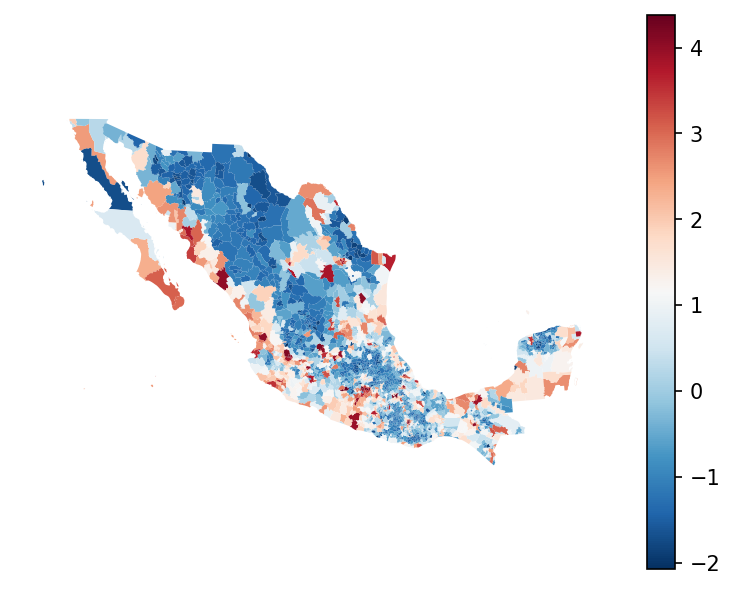

In [7]:
#gdf_map.plot(column="rr_mean", legend=True)
#set_axis_off()
#plt.show()

mun_map.plot(column="log_residual_burden", legend=True, cmap="RdBu_r")
plt.gca().set_axis_off()
out_path = r"C:\Users\Tosin\Downloads\BMC\BMC2\pooled_cli_adj_rl_risk.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print("saved:", out_path)
plt.show()

saved: C:\Users\Tosin\Downloads\BMC\BMC2\pooled_exceedance.png


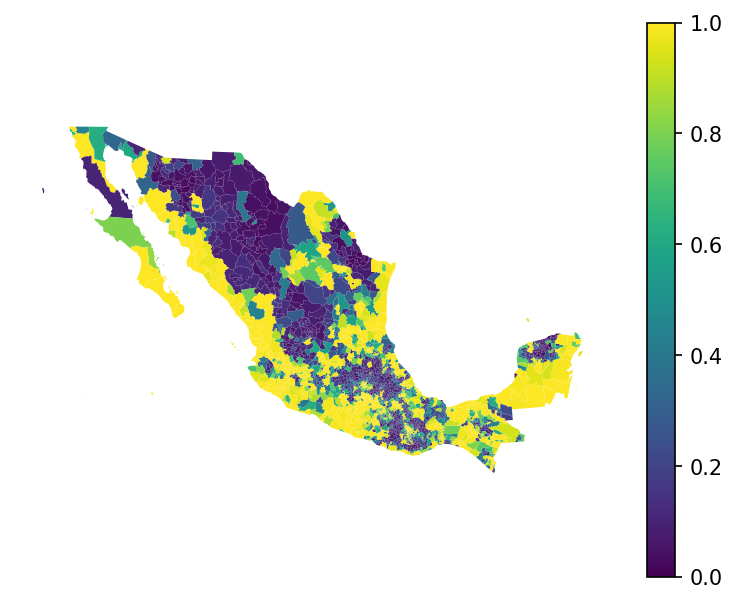

In [8]:
#gdf_map.plot(column="rr_mean", legend=True)
#set_axis_off()
#plt.show()
rr_post = np.exp(u_post)
prob_gt1 = (rr_post > 1.0).mean(axis=(0,1))
mun_map["prob_rr_gt1"] = prob_gt1


mun_map.plot(column="prob_rr_gt1", legend=True, vmin=0, vmax=1)
plt.gca().set_axis_off()
out_path = r"C:\Users\Tosin\Downloads\BMC\BMC2\pooled_exceedance.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight")
print("saved:", out_path)
plt.show()

<Figure size 1500x1500 with 0 Axes>

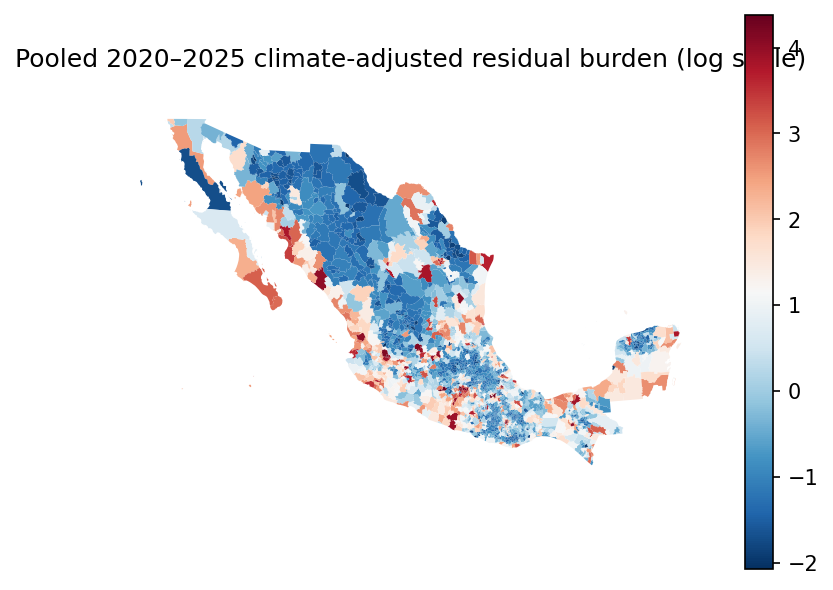

<Figure size 1500x1500 with 0 Axes>

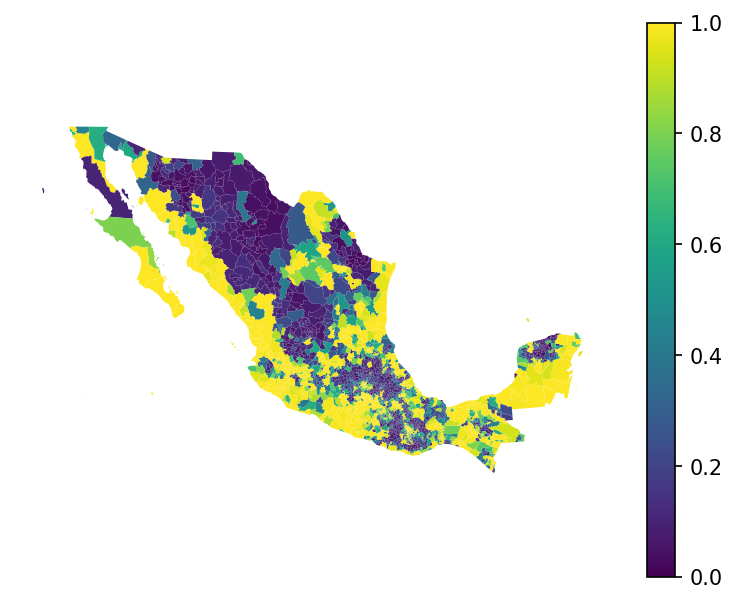

In [3]:
plt.figure(figsize=(10,10))
ax = mun_map.plot(column="log_residual_burden", legend=True, cmap="RdBu_r")
ax.set_axis_off()
ax.set_title("Pooled 2020–2025 climate-adjusted residual burden (log scale)")
plt.show()

# Exceedance probability: P(exp(u_centered) > 1)
rr_post = np.exp(u_post)
prob_gt1 = (rr_post > 1.0).mean(axis=(0,1))
mun_map["prob_rr_gt1"] = prob_gt1

plt.figure(figsize=(10,10))
ax = mun_map.plot(column="prob_rr_gt1", legend=True, vmin=0, vmax=1)
ax.set_axis_off()
#ax.set_title("Pooled 2020–2025 exceedance probability: P(relative burden > baseline)")
plt.show()

In [9]:
beta_post = idata_pool.posterior["beta"].to_numpy()
beta_flat = beta_post.reshape(-1, beta_post.shape[-1])

covariates = ["Temperature (SD)", "Rainfall (SD)", "Humidity (SD)"]

mean_beta = beta_flat.mean(axis=0)
low_beta  = np.quantile(beta_flat, 0.025, axis=0)
high_beta = np.quantile(beta_flat, 0.975, axis=0)

RR_mean = np.exp(mean_beta)
RR_low  = np.exp(low_beta)
RR_high = np.exp(high_beta)

for i in range(3):
    print(covariates[i], RR_mean[i], RR_low[i], RR_high[i])

Temperature (SD) 2.9387873856862483 2.3637488530961632 3.6775580859133727
Rainfall (SD) 1.0248672688825988 0.8244902204921987 1.2708403323493056
Humidity (SD) 0.9090725453165726 0.7461277673692156 1.1205142196838969


In [11]:
print("Has mun:", "mun" in globals())
print("Has pop:", "pop" in globals())
print("Has idx_m:", "idx_m" in globals())
print("Has Xz:", "Xz" in globals())
print("Has y:", "y" in globals())

Has mun: True
Has pop: False
Has idx_m: True
Has Xz: True
Has y: True


In [12]:

import numpy as np

# Ensure muni_code is int
mun["muni_code"] = mun["muni_code"].astype(int)

# If population already merged into mun, check:
if "population" not in mun.columns:
    pop_path = r"C:\Users\Tosin\Downloads\BMC\inegi_muni_population_2020.csv"
    pop = pd.read_csv(pop_path)
    pop["muni_code"] = pop["muni_code_int"].astype(int)
    mun = mun.merge(pop[["muni_code", "population"]], on="muni_code", how="left")

print("Missing population:", mun["population"].isna().sum())

log_pop_muni = np.log(mun["population"].to_numpy(dtype="float64"))

Missing population: 0


In [11]:
print("Has mun:", "mun" in globals())
print("Has pop:", "pop" in globals())
print("Has idx_m:", "idx_m" in globals())
print("Has Xz:", "Xz" in globals())
print("Has y:", "y" in globals())

Has mun: True
Has pop: False
Has idx_m: True
Has Xz: True
Has y: True


In [12]:
import numpy as np

# Ensure muni_code is int
mun["muni_code"] = mun["muni_code"].astype(int)

# If population already merged into mun, check:
if "population" not in mun.columns:
    pop_path = r"C:\Users\Tosin\Downloads\BMC\inegi_muni_population_2020.csv"
    pop = pd.read_csv(pop_path)
    pop["muni_code"] = pop["muni_code_int"].astype(int)
    mun = mun.merge(pop[["muni_code", "population"]], on="muni_code", how="left")

print("Missing population:", mun["population"].isna().sum())

log_pop_muni = np.log(mun["population"].to_numpy(dtype="float64"))

Missing population: 0
